Summary:

I tried to implement a neural network from scratch using numpy, but it was quite challenging at first. Therefore, I decided to start by studying code based on a more established NN framework. I went through the steps of initializing weights and biases, randomizing the data, and understanding the concepts of forward and backward propagation—although some of the mathematical implementations still remain unclear.
I was also unfamiliar with Jupyter and matplotlib initially, so I spent some time getting comfortable with the environment. Now I have built a basic foundation to further explore and learn more, but I still need to deepen my understanding of the underlying mathematical concepts.

Topic Directions:
1. Implement a CNN from scratch
Pros: Coding it yourself enables you to deeply understand the underlying principles.
Cons: It could be a significant amount of work, and you might need to further enhance your mathematical knowledge.

2. Compare your self-implemented CNN with advanced, mature CNN frameworks
Pros: This allows you to gain deeper insights into effective solutions based on your personal understanding.
Cons: On one hand, building a CNN from scratch requires substantial effort; on the other hand, understanding state-of-the-art frameworks may demand more background knowledge.

Epoch 1/20 | Loss: 2.1706 | Train Acc: 0.2772 | Test Acc: 0.4756
Epoch 2/20 | Loss: 1.7398 | Train Acc: 0.5849 | Test Acc: 0.6729
Epoch 3/20 | Loss: 1.4281 | Train Acc: 0.7128 | Test Acc: 0.7474
Epoch 4/20 | Loss: 1.1990 | Train Acc: 0.7648 | Test Acc: 0.7814
Epoch 5/20 | Loss: 1.0352 | Train Acc: 0.7921 | Test Acc: 0.8037
Epoch 6/20 | Loss: 0.9171 | Train Acc: 0.8089 | Test Acc: 0.8199
Epoch 7/20 | Loss: 0.8297 | Train Acc: 0.8231 | Test Acc: 0.8318
Epoch 8/20 | Loss: 0.7630 | Train Acc: 0.8327 | Test Acc: 0.8401
Epoch 9/20 | Loss: 0.7107 | Train Acc: 0.8407 | Test Acc: 0.8454
Epoch 10/20 | Loss: 0.6686 | Train Acc: 0.8473 | Test Acc: 0.8519
Epoch 11/20 | Loss: 0.6339 | Train Acc: 0.8526 | Test Acc: 0.8571
Epoch 12/20 | Loss: 0.6049 | Train Acc: 0.8568 | Test Acc: 0.8611
Epoch 13/20 | Loss: 0.5803 | Train Acc: 0.8606 | Test Acc: 0.8644
Epoch 14/20 | Loss: 0.5591 | Train Acc: 0.8641 | Test Acc: 0.8683
Epoch 15/20 | Loss: 0.5406 | Train Acc: 0.8672 | Test Acc: 0.8703
Epoch 16/20 | Loss:

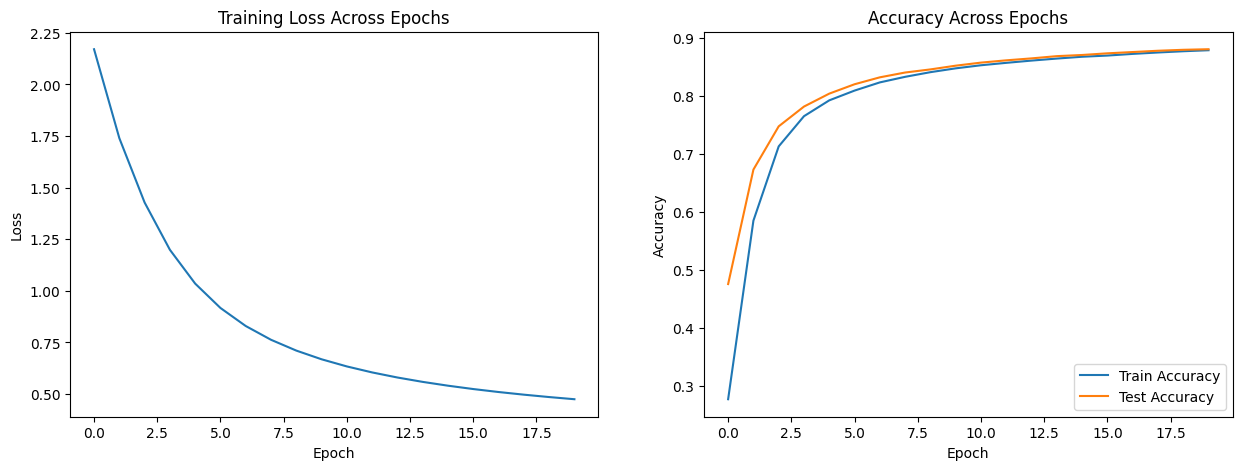

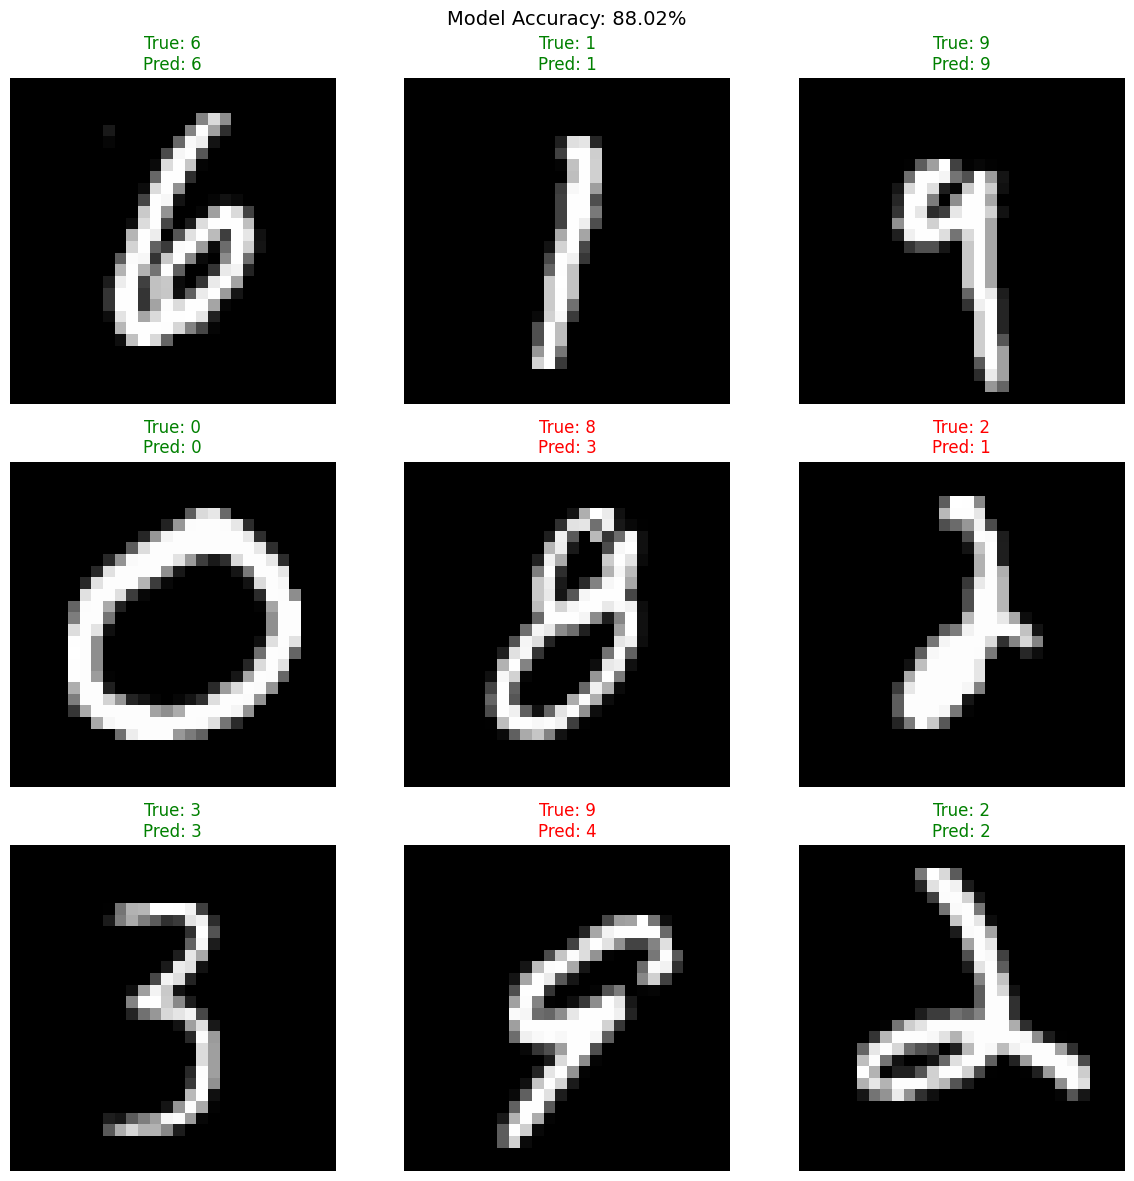

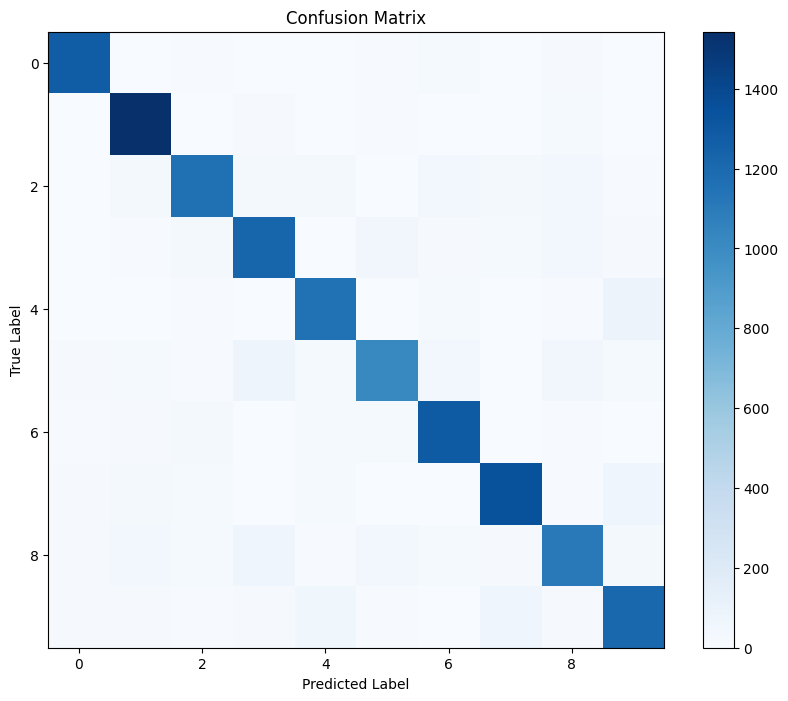

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# =============================================================================
# 1. Data Loading and Preprocessing
# =============================================================================
# Fetch the MNIST dataset from OpenML.
# The MNIST dataset consists of 70,000 images of handwritten digits.
# Here, we set as_frame=False to get the data in numpy array format.
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
# Normalize the pixel values to the range [0, 1] by converting to float32 and dividing by 255.
X = mnist.data.astype(np.float32) / 255.0  
# Convert the target labels to integer type.
y = mnist.target.astype(np.int32)

# Split the dataset into training and testing sets.
# 80% of the data is used for training, and 20% is reserved for testing.
# The random_state ensures that the split is reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================================================================
# 2. Neural Network Parameter Setup
# =============================================================================
# Define the key hyperparameters of our simple neural network.
input_size = 784  # Each image is 28x28 pixels, flattened into a vector of 784 elements.
hidden_size = 256 # Number of neurons in the hidden layer. This is a hyperparameter that can be adjusted.
output_size = 10  # Number of output classes (digits 0 through 9).
learning_rate = 0.001  # Learning rate for the gradient descent optimization.
epochs = 20  # Number of full passes (epochs) over the entire training set.
batch_size = 128  # Number of samples to process in each mini-batch.

# =============================================================================
# 3. Parameter Initialization (He Initialization)
# =============================================================================
# We initialize the network parameters: weights and biases.
# He initialization is used for weights to help maintain proper signal flow with ReLU activations.
np.random.seed(42)  # Set a random seed to ensure reproducibility of results.
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)  # Weights from input layer to hidden layer.
b1 = np.zeros(hidden_size)  # Initialize biases for the hidden layer to zeros.
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)  # Weights from hidden layer to output layer.
b2 = np.zeros(output_size)  # Initialize biases for the output layer to zeros.

# =============================================================================
# 4. Activation Function Definitions
# =============================================================================
def relu(x):
    """
    Apply the ReLU (Rectified Linear Unit) activation function.
    
    ReLU sets all negative values in the input x to zero, while keeping positive values unchanged.
    
    Parameters:
    x (numpy array): The input data array.
    
    Returns:
    numpy array: The output array after applying the ReLU function element-wise.
    """
    return np.maximum(0, x)

def softmax(x):
    """
    Compute the softmax function on the input data.
    
    Softmax converts a vector of raw scores (logits) into probabilities,
    ensuring that the sum of the probabilities for each sample equals 1.
    For numerical stability, we subtract the maximum value in x before exponentiation.
    
    Parameters:
    x (numpy array): The input data array with shape (n_samples, n_classes).
    
    Returns:
    numpy array: The output probability distribution with the same shape as x.
    """
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)

# =============================================================================
# 5. Variables for Tracking Training and Testing Metrics
# =============================================================================
train_loss = []  # List to record the average loss value for each epoch.
train_acc = []   # List to record the training accuracy for each epoch.
test_acc = []    # List to record the test accuracy for each epoch.

# =============================================================================
# 6. Training Loop
# =============================================================================
for epoch in range(epochs):
    epoch_loss = 0  # Initialize the cumulative loss for the current epoch.
    correct = 0     # Counter for the number of correct predictions in the epoch.
    
    # Shuffle the training data at the beginning of each epoch to ensure each mini-batch is representative.
    permutation = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train[permutation]
    
    # Process the training data in mini-batches.
    for i in range(0, X_train.shape[0], batch_size):
        # Extract a mini-batch of input data and corresponding labels.
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        current_batch_size = X_batch.shape[0]
        
        # -------------------------
        # Forward Propagation
        # -------------------------
        # Compute the activations for the hidden layer.
        z1 = X_batch.dot(W1) + b1  # Compute the linear combination for the hidden layer.
        a1 = relu(z1)             # Apply ReLU activation function.
        
        # Compute the activations for the output layer.
        z2 = a1.dot(W2) + b2      # Compute the linear combination for the output layer.
        a2 = softmax(z2)          # Apply softmax to obtain probability distributions over classes.
        
        # -------------------------
        # Loss Computation
        # -------------------------
        # Calculate the cross-entropy loss for the mini-batch.
        # A small value (1e-8) is added to avoid log(0) issues.
        loss = -np.mean(np.log(a2[np.arange(current_batch_size), y_batch] + 1e-8))
        epoch_loss += loss * current_batch_size  # Accumulate batch loss, weighted by the number of samples.
        
        # -------------------------
        # Backpropagation
        # -------------------------
        # Compute the gradients for the output layer.
        grad_z2 = a2.copy()
        # Adjust the gradients with respect to the true class labels.
        grad_z2[np.arange(current_batch_size), y_batch] -= 1
        grad_z2 /= current_batch_size  # Normalize the gradient over the mini-batch.
        
        # Gradients for output layer weights and biases.
        grad_W2 = a1.T.dot(grad_z2)
        grad_b2 = np.sum(grad_z2, axis=0)
        
        # Backpropagate the gradient to the hidden layer.
        grad_a1 = grad_z2.dot(W2.T)
        # Compute the gradient with respect to z1 using the derivative of the ReLU function.
        grad_z1 = grad_a1 * (z1 > 0)
        
        # Gradients for hidden layer weights and biases.
        grad_W1 = X_batch.T.dot(grad_z1)
        grad_b1 = np.sum(grad_z1, axis=0)
        
        # -------------------------
        # Parameter Update Using Gradient Descent
        # -------------------------
        # Update the weights and biases by subtracting the product of the learning rate and the respective gradients.
        W1 -= learning_rate * grad_W1
        b1 -= learning_rate * grad_b1
        W2 -= learning_rate * grad_W2
        b2 -= learning_rate * grad_b2
        
        # -------------------------
        # Accuracy Calculation for the Batch
        # -------------------------
        # Determine the predicted classes by selecting the index with the maximum probability.
        pred = np.argmax(a2, axis=1)
        # Compare predictions with the true labels and accumulate the count of correct predictions.
        correct += np.sum(pred == y_batch)
    
    # Calculate and record the average loss over the epoch.
    avg_loss = epoch_loss / X_train.shape[0]
    train_loss.append(avg_loss)
    
    # Record the training accuracy for the current epoch.
    train_acc.append(correct / X_train.shape[0])
    
    # -------------------------------------
    # Evaluation on the Test Set
    # -------------------------------------
    # Conduct a forward pass on the test data (without backpropagation) to evaluate performance.
    z1_test = X_test.dot(W1) + b1
    a1_test = relu(z1_test)
    z2_test = a1_test.dot(W2) + b2
    # Obtain the predicted class labels for test data.
    test_pred = np.argmax(z2_test, axis=1)
    # Compute test accuracy using the accuracy_score metric from scikit-learn.
    test_acc.append(accuracy_score(y_test, test_pred))
    
    # Print detailed results for the current epoch.
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc[-1]:.4f} | Test Acc: {test_acc[-1]:.4f}")

# =============================================================================
# 7. Visualization of Training Progress and Predictions
# =============================================================================
# Plot the training loss and the accuracy curves for both train and test sets.

plt.figure(figsize=(15,5))

# Plot the loss curve over the epochs.
plt.subplot(1,2,1)
plt.plot(train_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Epochs")

# Plot the training and test accuracy curves.
plt.subplot(1,2,2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Across Epochs")
plt.legend()
plt.show()

# -------------------------------------
# Visualize Sample Predictions on Test Data
# -------------------------------------
# Re-run the forward pass on test data to get the final predictions.
z1_test = X_test.dot(W1) + b1
a1_test = relu(z1_test)
z2_test = a1_test.dot(W2) + b2
test_pred = np.argmax(z2_test, axis=1)

# Set a fixed random seed to ensure consistent results in sample selection.
np.random.seed(42)
# Identify indices where the model predictions are correct.
correct_idx = np.where(test_pred == y_test)[0]
# Identify indices where the model predictions are incorrect.
wrong_idx = np.where(test_pred != y_test)[0]

# (Optional) Select a fixed number of correct and incorrect examples.
# Here, we randomly choose 3 correct predictions and 6 incorrect predictions.
show_correct = np.random.choice(correct_idx, 3, replace=False)
show_wrong = np.random.choice(wrong_idx, 6, replace=False)
# Alternatively, randomly select any 9 samples from the test set.
selected_idx = np.random.choice(len(y_test), 9, replace=False)

# Create a 3x3 grid to display selected test images along with their true and predicted labels.
plt.figure(figsize=(12, 12))
for i, idx in enumerate(selected_idx):
    plt.subplot(3, 3, i+1)
    # Reshape the 784-dimensional input back into a 28x28 image.
    # Multiply by 255 to scale back to the standard pixel range 0-255 for display.
    img = X_test[idx].reshape(28, 28) * 255  
    plt.imshow(img, cmap='gray')
    true_label = y_test[idx]
    pred_label = test_pred[idx]
    
    # Use color coding for the title: green indicates a correct prediction, red indicates an error.
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

# Add an overall title displaying the model's test accuracy.
plt.suptitle(f"Model Accuracy: {accuracy_score(y_test, test_pred):.2%}", fontsize=14)
plt.tight_layout()
plt.show()

# =============================================================================
# 8. Confusion Matrix Visualization
# =============================================================================
# Compute the confusion matrix, which provides an overview of prediction errors.
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()